***Ejercicio 1 — Agrupación básica***

Objetivo: Entender cómo el algoritmo une puntos cercanos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [4]:
X = np.array([
    [1, 1],
    [2, 1],
    [5, 5],
    [6, 5],
    [10,10],
    [11,10]
])
etiquetas = ['A', 'B', 'C', 'D', 'E', 'F']

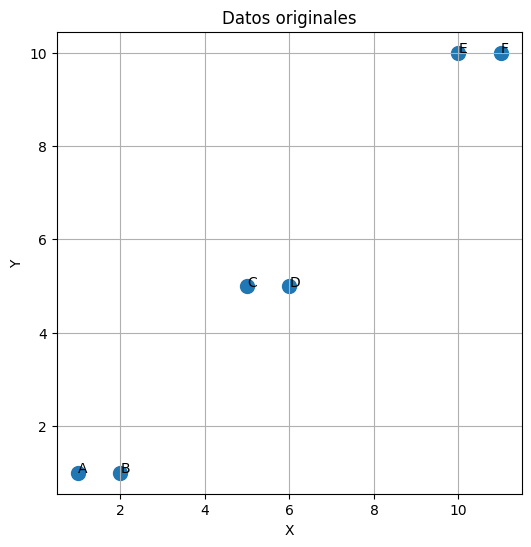

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=100)
for i, txt in enumerate(etiquetas):
    plt.annotate(txt, (X[i,0], X[i,1]))
plt.title('Datos originales')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [7]:
Z = linkage(X, method='ward')

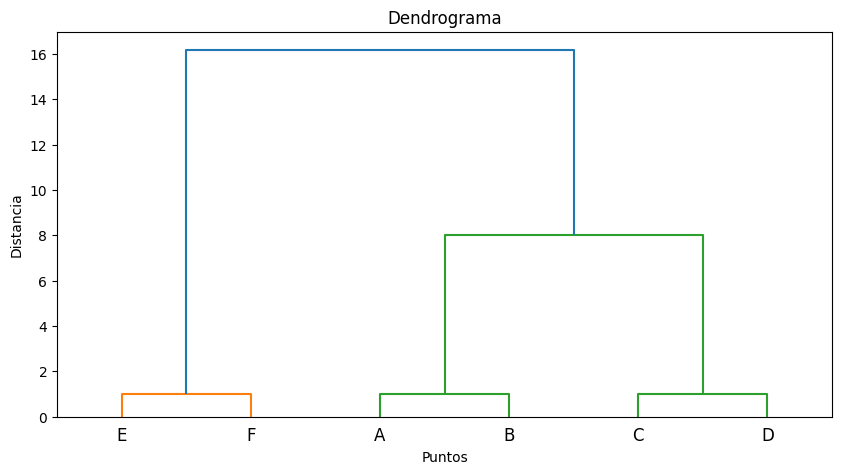

In [8]:
plt.figure(figsize=(10,5))
dendrogram(
    Z,
    labels=etiquetas
)

plt.title('Dendrograma')
plt.xlabel('Puntos')
plt.ylabel('Distancia')
plt.show()

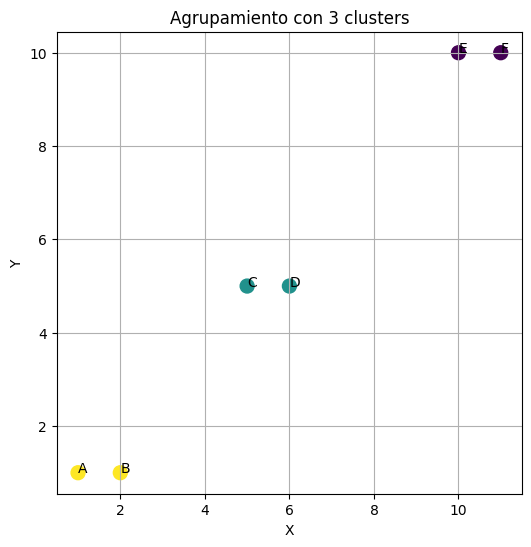

In [9]:
modelo_3 = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

clusters_3 = modelo_3.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters_3,
    s=100
)

for i, txt in enumerate(etiquetas):
    plt.annotate(txt, (X[i,0], X[i,1]))

plt.title('Agrupamiento con 3 clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()


In [13]:
print("clusters con 3 grupos:")
for punto, cluster in zip(etiquetas, clusters_3):
    print(punto, "-> cluster", cluster)

clusters con 3 grupos:
A -> cluster 2
B -> cluster 2
C -> cluster 1
D -> cluster 1
E -> cluster 0
F -> cluster 0


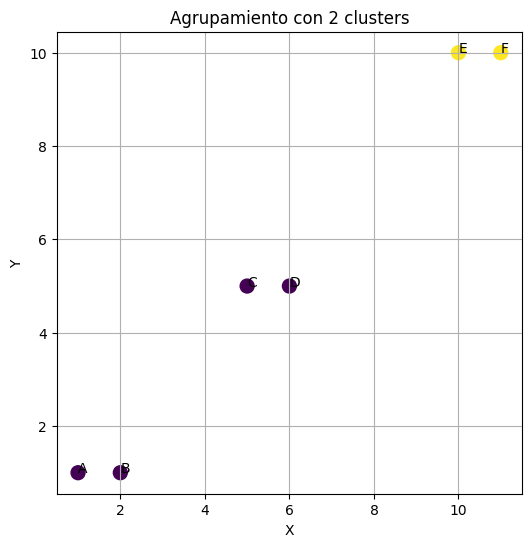

In [10]:
modelo_2 = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

clusters_2 = modelo_2.fit_predict(X)
plt.figure(figsize=(6,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters_2,
    s=100
)

for i, txt in enumerate(etiquetas):
    plt.annotate(txt, (X[i,0], X[i,1]))

plt.title('Agrupamiento con 2 clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [12]:
print("\nclusters con 2 grupos:")
for punto, cluster in zip(etiquetas, clusters_2):
    print(punto, "-> cluster", cluster)


clusters con 2 grupos:
A -> cluster 0
B -> cluster 0
C -> cluster 0
D -> cluster 0
E -> cluster 1
F -> cluster 1


**¿Qué puntos se unen primero y por qué?**

Los primeros puntos que se unen son:
A y B,
C y D,
E y F.

Porque son los pares que tienen menor distancia entre si.

**¿Qué sucede al cortar el dendrograma en una altura pequeña?**

Se forman muchos clusters pequeños, ya que solo se unen los puntos muy cercanos.

**¿Qué cambia al cortar el árbol más arriba?**

Los clusters comienzan a fusionarse y se forman grupos más grandes.

**¿Qué significa la altura donde se unen dos ramas?**

La altura representa la distancia o diferencia entre los grupos que se están uniendo.

**¿Cuántos clusters aparecen al cortar aproximadamente en distancia 8?**

Aproximadamente aparecen 2 clusters principales:

Cluster 1: A, B, C y D
Cluster 2: E y F